In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Optional
import torch.nn.functional as F

from model import Transformer, make_src_mask, make_tgt_mask
from matplotlib.ticker import FormatStrFormatter
from tqdm import tqdm

from config import *

from dataset_cfd import *
from lr_scheduler import *
from train import *

import numpy as np
import matplotlib.pyplot as plt

import json
import os

In [2]:
config = {
        "grid_size"        : 64,
        "patch_size"       : 8,
        "patch_dim"        : 8*8*2 + (4 * 16),
        "d_model"          : 512,
        "N"                : 6,
        "num_heads"        : 8,
        "d_ff"             : 1024,
        "dropout"          : 0.01,
        "train_batch_size" : 8,
        "test_batch_size"  : 8,
        "epochs"           : 500,
        "device"           : 'cuda' if torch.cuda.is_available() else 'cpu',
        "save_every"       : 20
    }

transformer = Transformer(
                        d_model        = config["d_model"],
                        N              = config["N"],
                        num_heads      = config["num_heads"],
                        d_ff           = config["d_ff"],
                        patch_dim      = config['patch_dim'])

In [3]:
load_checkpoint("checkpoint_with_P.pt", transformer)

149

In [4]:
sum(p.numel() for p in transformer.parameters())

35421376

In [5]:
def fourier_features(cords: torch.tensor, num_freq = 16):
    # [num_patches, 2] -> [num_patches, C * num_freq * 2]
    freqs = 2 ** torch.linspace(0, num_freq - 1, num_freq)                   # [num_freqs]
    angles = (cords.unsqueeze(-1) * freqs * 2 * torch.pi)                    # [num_patches, C, num_freq]
    encoded = torch.cat([torch.sin(angles), torch.cos(angles)], dim = -1)    # [num_patches, C, num_freq * 2]
    return encoded.view(cords.shape[0], -1)                                  # [num_patches, C * num_freq * 2]


patches_per_side = config["grid_size"] // config["patch_size"]
coords = []
for row in range(patches_per_side):
    for col in range(patches_per_side):
        coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
coords_tensor = torch.tensor(coords, dtype=torch.float32)


# coords_tensor = fourier_features(coords_tensor)
# coords_tensor.shape


In [6]:
with open("train_test_re.json", "r", encoding="utf-8") as file:
    train_test_re = json.load(file)

In [7]:
pre_train_re  = sorted([float(i.split('.csv')[0].split("Re_")[-1]) for i in os.listdir("Data_with_P")])
post_train_re = sorted(train_test_re['test_re'] + train_test_re['train_re'])
pre_train_re

[0.1,
 8.43,
 16.76,
 20.0,
 25.09,
 33.42,
 41.75,
 45.0,
 50.08,
 58.41,
 66.74,
 70.0,
 75.07,
 83.4,
 91.73,
 95.0,
 100.06,
 108.39,
 116.72,
 120.0,
 125.05,
 133.38,
 141.71,
 145.0,
 150.04,
 158.37,
 166.7,
 170.0,
 175.03,
 183.36,
 191.69,
 195.0,
 200.02,
 208.35,
 216.68,
 220.0,
 225.01,
 233.34,
 241.67,
 245.0,
 250.0,
 258.33,
 266.66,
 270.0,
 274.99,
 283.32,
 291.65,
 295.0,
 299.98,
 308.31,
 316.64,
 320.0,
 324.97,
 333.3,
 341.63,
 345.0,
 349.96,
 358.29,
 366.62,
 370.0,
 374.95,
 383.28,
 391.61,
 395.0,
 399.94,
 408.27,
 416.6,
 420.0,
 424.93,
 433.26,
 441.59,
 445.0,
 449.92,
 458.25,
 466.58,
 470.0,
 474.91,
 483.24,
 491.57,
 495.0,
 499.9,
 508.23,
 516.56,
 524.89,
 533.22,
 541.55,
 549.88,
 558.21,
 566.54,
 574.87,
 583.2,
 591.53,
 599.86,
 608.19,
 616.52,
 624.85,
 633.18,
 641.51,
 649.84,
 658.17,
 666.5,
 674.83,
 683.16,
 691.49,
 699.82,
 708.15,
 716.48,
 724.81,
 733.14,
 741.47,
 749.8,
 758.13,
 766.46,
 774.79,
 783.12,
 791.45,
 799

In [8]:
def patches_to_contour(patch, num_patches, patch_size, grid_size):

    unrolled = patch.view(num_patches, num_patches, 2, patch_size, patch_size)   # (patch_row, patch_col, C, patch_h, patch_w)
    unrolled = unrolled.permute(2, 0, 3, 1, 4).contiguous()                      # (C, patch_row, patch_h, patch_col, patch_w)
    unrolled = unrolled.view(2, grid_size, grid_size)                            # (2, grid_size, grid_size)

    return unrolled

def predict(re_value, model, re_mean, re_std, u_mean, u_std, v_mean, v_std, config, device="cpu", plot: bool = True):
    # normalize using dataset stats
    re_norm = (re_value - re_mean) / re_std
    src = torch.tensor([[re_norm]], dtype=torch.float32).to(device)  # (1, 1)

    patches_per_side = config["grid_size"] // config["patch_size"]
    coords = []
    for row in range(patches_per_side):
        for col in range(patches_per_side):
            coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
    coords_tensor = torch.tensor(coords, dtype=torch.float32)


    coords_tensor = fourier_features(coords_tensor)

    # decode
    src_mask = make_src_mask(src, -1)
    pred_patches = greedy_decode(
        model, src, src_mask,
        max_len  = (config["grid_size"] // config["patch_size"])**2,
        patch_dim = config["patch_dim"] - (4 * 16), coords_tensor=coords_tensor,
        device   = device, num_freq = 16
    )  # (1, num_patches, patch_dim)

    # pred_patches = pred_patches[:, :, :-2]

    # unroll patches to (2, 64, 64)
    unrolled = patches_to_contour(pred_patches[0],
                                   config["grid_size"] // config["patch_size"],
                                   config["patch_size"],
                                   config["grid_size"])


    u = unrolled[0].detach().cpu()
    v = unrolled[1].detach().cpu()



    # denormalize
    u = (u * u_std) + u_mean
    v = (v * v_std) + v_mean

    # numerical gradients
    u_np = u
    v_np = v
    du_dx = np.gradient(u_np, axis=1)  # derivative along x (cols)
    dv_dy = np.gradient(v_np, axis=0)  # derivative along y (rows)

    divergence = du_dx + dv_dy

    mag = np.sqrt(u**2 + v**2)

    if plot:
        # u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
        # v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

        # plot
        x_grid = np.linspace(0, 1, config["grid_size"])
        y_grid = np.linspace(0, 1, config["grid_size"])

        

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        c0 = axes[0].contourf(x_grid, y_grid, u, levels=50, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        c1 = axes[1].contourf(x_grid, y_grid, v, levels=50, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        c2 = axes[2].contourf(x_grid, y_grid, mag, levels=50, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        # axes[2].streamplot(x_grid, y_grid, u, v, color="white", density=1.2)

        axes[2].set_title("|U| + streamlines")


        c3 = axes[3].contourf(divergence, levels=50, cmap="RdBu")
        fig.colorbar(c3, ax=axes[3], label="∇·u")
        axes[3].set_title(f"divergence mean: {divergence.mean():.2f}")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, divergence, mag


100%|██████████| 64/64 [00:00<00:00, 71.93it/s]


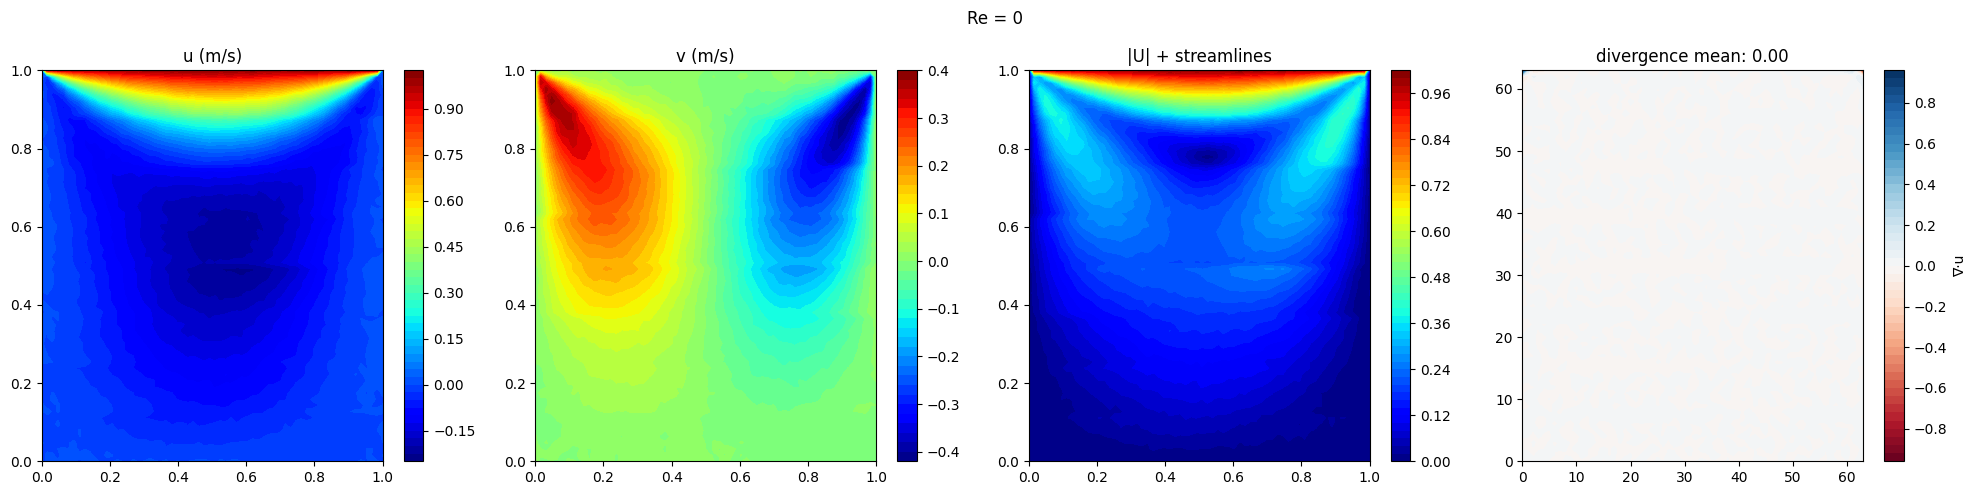

100%|██████████| 64/64 [00:00<00:00, 70.64it/s]


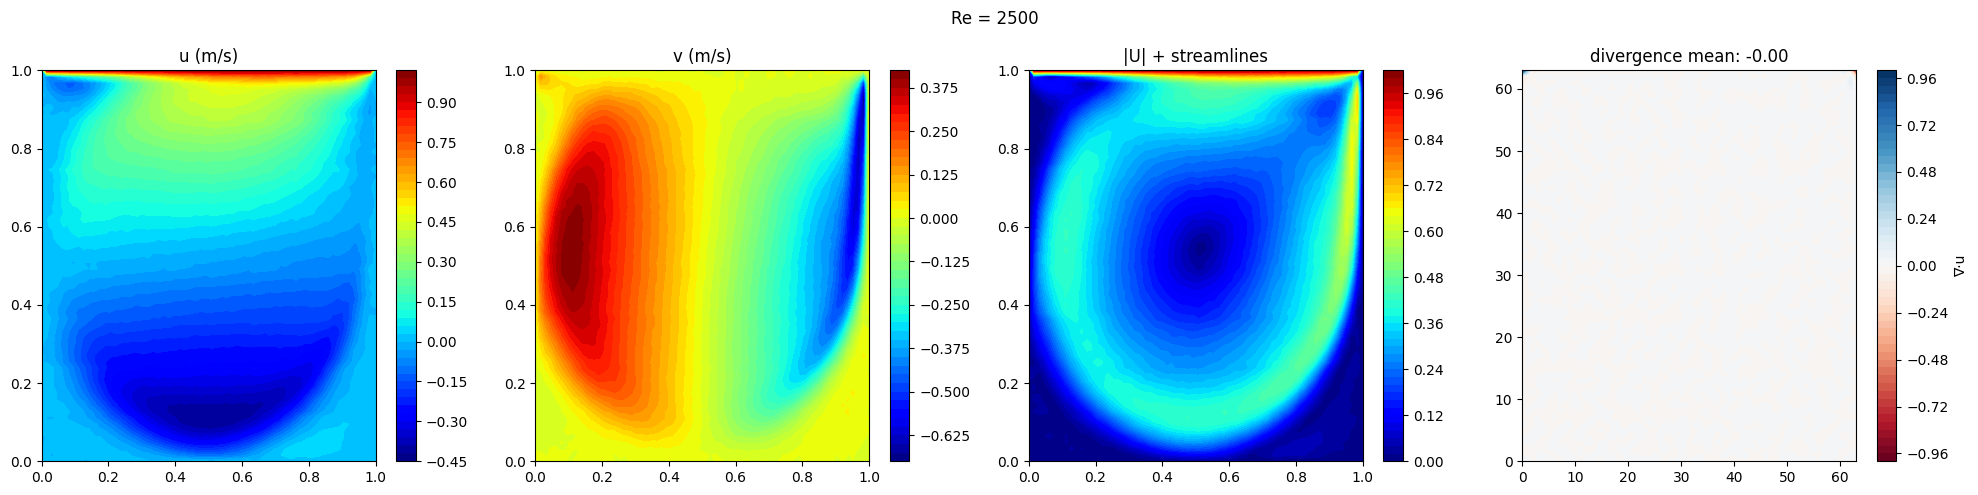

tensor(0.3427)

In [40]:
re = 5000
u_1, v_1, divergence_1, mag_1 = predict(re_value = 0, model = transformer, re_mean = RE_MEAN, re_std = RE_STD, u_mean = U_MEAN, u_std = U_STD, v_mean = V_MEAN, v_std = V_STD, config = config, plot = True)
u_2, v_2, divergence_2, mag_2 = predict(re_value = 2500, model = transformer, re_mean = RE_MEAN, re_std = RE_STD, u_mean = U_MEAN, u_std = U_STD, v_mean = V_MEAN, v_std = V_STD, config = config, plot = True)


torch.mean(((mag_1**2) + (mag_2**2))**0.5)

In [34]:
torch.abs(mag_1 - mag_2).mean()

tensor(0.1402)

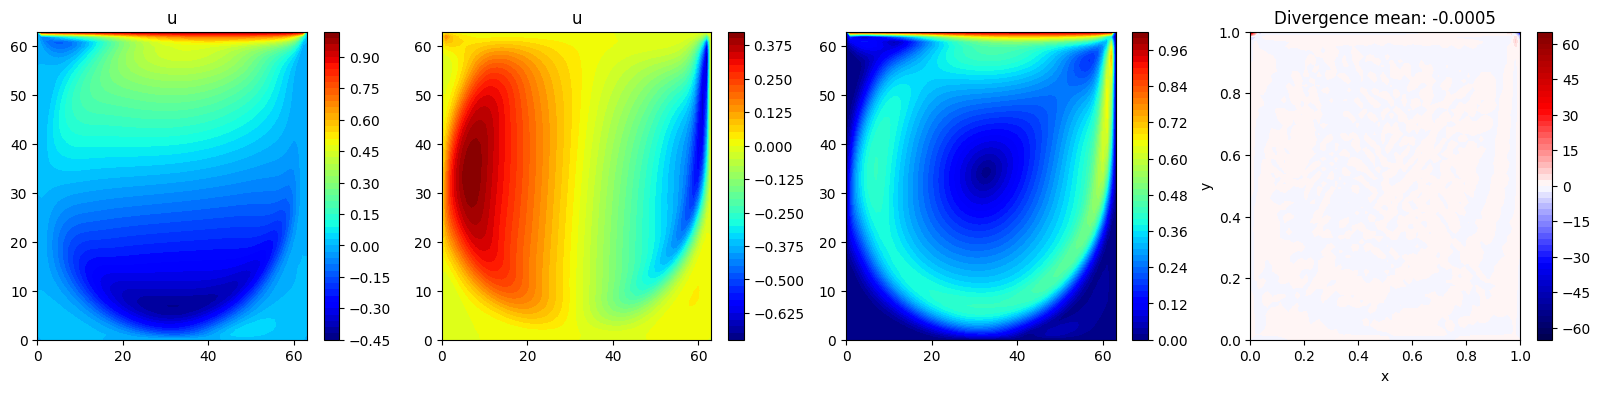

In [9]:
def ground_truth(re: float, plot: bool):

    assert f"Re_{re}.csv" in os.listdir("Data_with_P"), "make sure re is in the csv folder"

    df = pd.read_csv(f"Data_with_P/Re_{re}.csv", index_col = 0)

    lin = np.linspace(0, 1, 64)

    x = df['x']
    y = df['y']
    u = df["u (m/s)"].values.astype(np.float32)
    v = df["v (m/s)"].values.astype(np.float32)

    points = np.stack([x, y], axis=1)  # (N, 2)
    # interpolate u and v onto regular grid

    grid_x, grid_y = np.meshgrid(lin, lin) # (grid_size, grid_size)


    u_grid = griddata(points, u, (grid_x, grid_y), method="linear", fill_value=0.0)
    v_grid = griddata(points, v, (grid_x, grid_y), method="linear", fill_value=0.0)

    dx = lin[1] - lin[0]
    dy = lin[1] - lin[0]

    # gradients
    du_dx = np.gradient(u_grid, dx, axis=1)
    dv_dy = np.gradient(v_grid, dy, axis=0)

    # divergence
    div = du_dx + dv_dy

    mag = np.sqrt(u_grid**2 + v_grid**2)
    
    if plot:
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))

        u_c = axes[0].contourf(u_grid, levels=50, cmap="jet")
        plt.colorbar(u_c, ax=axes[0])
        axes[0].set_title("u")

        v_c = axes[1].contourf(v_grid, levels=50, cmap="jet")
        plt.colorbar(v_c, ax=axes[1])
        axes[1].set_title("u")

        
        mag_c = axes[2].contourf(mag, levels=50, cmap="jet")

        plt.colorbar(mag_c, ax=axes[2])

        
        div_c = axes[3].contourf(grid_x, grid_y, div, levels=50, cmap="seismic")
        plt.colorbar(div_c, ax=axes[3])
        axes[3].set_title(f"Divergence mean: {div.mean():.4f}")
        axes[3].set_xlabel("x")
        axes[3].set_ylabel("y")

        plt.show()
    
    return u_grid, v_grid, div, mag

u_grid, v_grid, div, mag = ground_truth(re = 2499.1, plot=True)

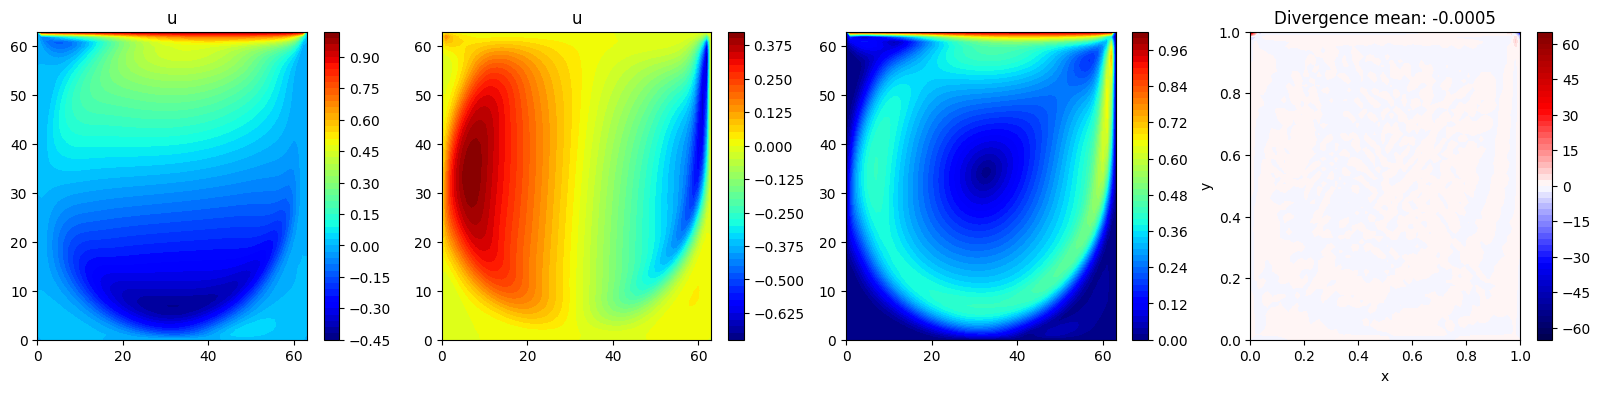

100%|██████████| 64/64 [00:01<00:00, 55.40it/s]


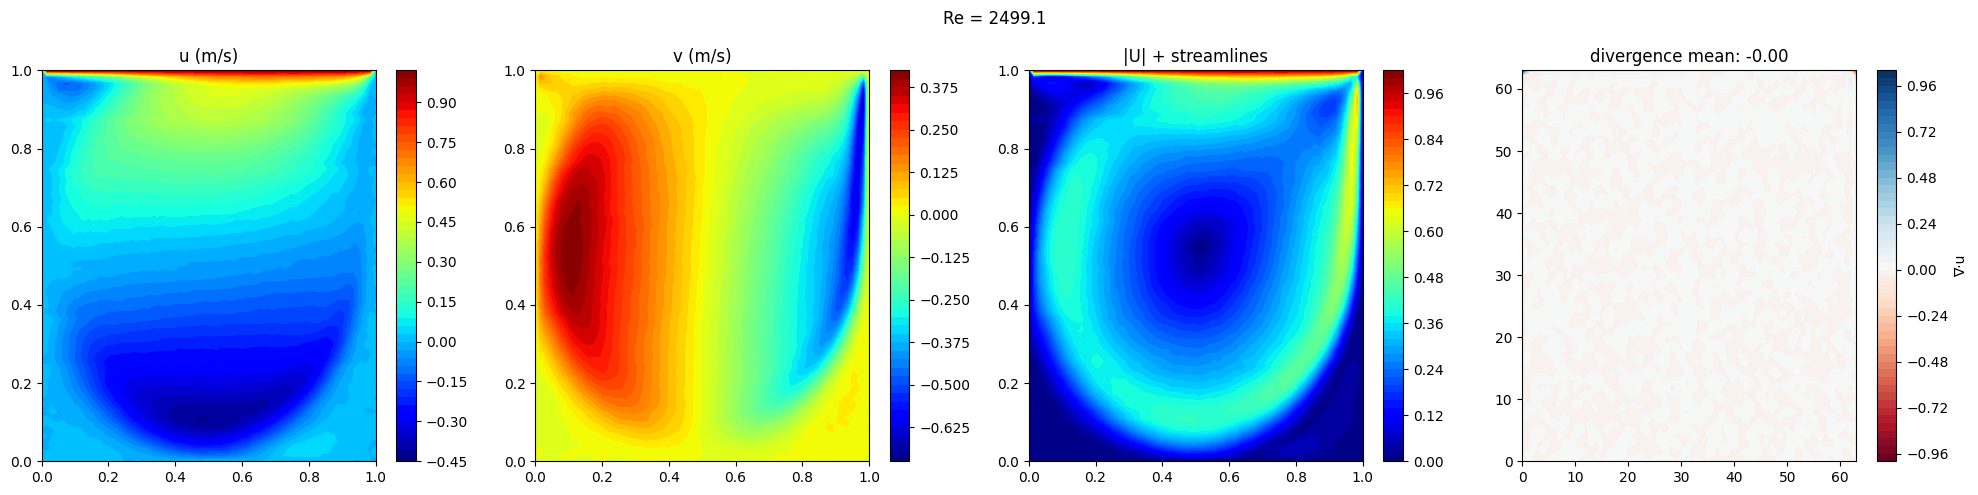

In [10]:
re = 2499.1
u_grid_actual, v_grid_actual, div_actual, mag_actual = ground_truth(re = re, plot=True)

u_grid_pred, v_grid_pred, div_pred, mag_pred = predict(re_value = re, model = transformer, 
                                               re_mean = RE_MEAN, re_std = RE_STD, u_mean = U_MEAN, u_std = U_STD, v_mean = V_MEAN, v_std = V_STD, 
                                               config = config, device = "cpu", plot = True)

In [ ]:
errors = {}
frames = []

for re_idx in range(len(pre_train_re)):

    err = {}

    u_grid_actual, v_grid_actual, div_actual, mag_actual = ground_truth(re = pre_train_re[re_idx], plot = False)

    u_grid_pred, v_grid_pred, div_pred, mag_pred = predict(re_value = pre_train_re[re_idx], model = transformer, 
                                                            re_mean = RE_MEAN, re_std = RE_STD, u_mean = U_MEAN, u_std = U_STD, v_mean = V_MEAN, v_std = V_STD, 
                                                            config = config, device = "cpu", plot = False)


    u_difference = torch.abs((torch.tensor(u_grid_actual) - u_grid_pred)**2)
    v_difference = torch.abs((torch.tensor(v_grid_actual) - v_grid_pred)**2)
    mag_difference = torch.abs((torch.tensor(mag_actual) - mag_pred))

    err["u_error"]   = (((torch.tensor(u_grid_actual)**2) + (u_grid_pred**2))**0.5).mean().item()
    err["v_error"]   = (((torch.tensor(v_grid_actual)**2) + (v_grid_pred**2))**0.5).mean().item()
    err["mag_error"] = (((torch.tensor(mag_actual)**2) + (mag_pred**2))**0.5).mean().item()
    err["isTrain"]   = True if post_train_re[re_idx] in train_test_re['train_re'] else False

    errors[pre_train_re[re_idx]] = err

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    lin = torch.linspace(0,1,64)

    u_diff_cbar = axes[0].contourf(lin, lin, mag_actual, cmap = "jet", levels = 100)
    cbar = plt.colorbar(u_diff_cbar, ax = axes[0])
    ticks = cbar.get_ticks()
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])
    axes[0].set_title("Magnitude - Actual")

    v_diff_cbar = axes[1].contourf(lin, lin, mag_pred, cmap = "jet", levels = 100)
    cbar = plt.colorbar(v_diff_cbar, ax = axes[1])
    ticks = cbar.get_ticks()
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])
    axes[1].set_title("Magnitude - Prediction")

    mag_diff_cbar = axes[2].contourf(lin, lin, mag_difference, levels = 100, cmap = "hot")
    cbar = plt.colorbar(mag_diff_cbar, ax = axes[2])
    ticks = cbar.get_ticks()
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])
    axes[2].set_title("|$mag_{pred} - mag_{actual}$|")

    # predicted divergence
    div_contour = axes[3].contourf(lin, lin, div_pred, levels = 100, cmap = "BuPu")
    cbar = plt.colorbar(div_contour, ax=axes[3])
    ticks = cbar.get_ticks()
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

    # plt.colorbar(cbar, ax = axes[3])
    axes[3].set_title(f"Average Predicted $\\nabla \cdot u$: {div_pred.mean():4f}")

    plt.suptitle(f"Re: {pre_train_re[re_idx]}")
    plt.tight_layout()

    fig.canvas.draw()
    frame = np.asarray(fig.canvas.renderer.buffer_rgba())
    frames.append(frame)
    plt.close(fig)
    # plt.show()


    # break

100%|██████████| 64/64 [00:00<00:00, 89.28it/s] 


In [12]:
import imageio.v2 as imageio
imageio.mimsave("velocity_magnitude_comparison.mp4", frames, fps=10)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2000, 500) to (2000, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


,Re,u_error,v_error,mag_error,isTrain
0,0.10,NaN,NaN,NaN,False
1,8.43,NaN,NaN,NaN,True
2,16.76,NaN,NaN,NaN,True
3,20.00,NaN,NaN,NaN,True
4,25.09,NaN,NaN,NaN,False
...,...,...,...,...,...
316,2465.80,NaN,NaN,NaN,True
317,2474.10,NaN,NaN,NaN,True
318,2482.40,NaN,NaN,NaN,True
319,2490.80,NaN,NaN,NaN,True


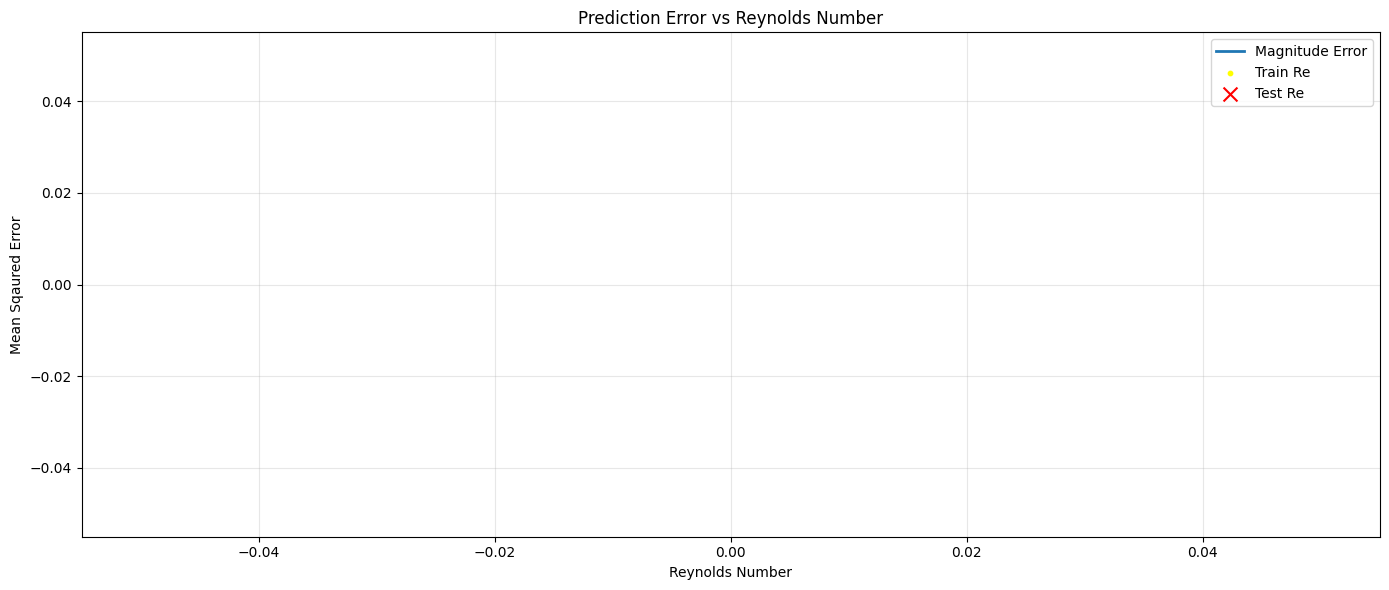

In [13]:
df = pd.DataFrame(errors).T.reset_index()
df = df.rename(columns={"index": "Re"})
df = df.sort_values("Re")

train_df = df[df["isTrain"]]
test_df  = df[df['isTrain'] == False]

plt.figure(figsize=(14, 6))

# Lines
# plt.plot(df["Re"], df["u_error"], label="U Error", linewidth=0.1)
# plt.plot(df["Re"], df["v_error"], label="V Error", linewidth=0.1)
plt.plot(df["Re"], df["mag_error"], label="Magnitude Error", linewidth=2)

# Train points
plt.scatter(
    train_df["Re"],
    train_df["mag_error"],
    marker="o",
    s=10,
    label="Train Re",
    color = "yellow"
)

# Test points
plt.scatter(
    test_df["Re"],
    test_df["mag_error"],
    marker="x",
    s=100,
    label="Test Re", color = "red",
)

plt.xlabel("Reynolds Number")
plt.ylabel("Mean Sqaured Error")
plt.title("Prediction Error vs Reynolds Number")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
max_mag_error = max(
    errors[re]["mag_error"]
    for re in errors
)

min_mag_error = 0.0
max_mag_error

nan

In [15]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import numpy as np
import torch

errors = {}
frames = []
cache  = {}

# ==========================================================
# PASS 1
# Compute predictions once and collect global colorbar ranges
# ==========================================================

global_mag_min = np.inf
global_mag_max = -np.inf
min_mag_error  = np.inf
max_mag_error  = -np.inf

for re in sorted(pre_train_re):

    # ground truth
    u_gt, v_gt, div_gt, mag_gt = ground_truth(re=re, plot=False)

    # prediction
    u_pred, v_pred, div_pred, mag_pred = predict(
        re_value = re,
        model    = transformer,
        re_mean  = RE_MEAN,
        re_std   = RE_STD,
        u_mean   = U_MEAN,
        u_std    = U_STD,
        v_mean   = V_MEAN,
        v_std    = V_STD,
        config   = config,
        device   = "cpu",
        plot     = False
    )

    # convert tensors -> numpy
    u_pred_np   = u_pred.detach().cpu().numpy()   if torch.is_tensor(u_pred)   else np.array(u_pred)
    v_pred_np   = v_pred.detach().cpu().numpy()   if torch.is_tensor(v_pred)   else np.array(v_pred)
    mag_pred_np = mag_pred.detach().cpu().numpy() if torch.is_tensor(mag_pred) else np.array(mag_pred)
    mag_gt_np   = mag_gt.detach().cpu().numpy()   if torch.is_tensor(mag_gt)   else np.array(mag_gt)
    u_gt_np     = u_gt.detach().cpu().numpy()     if torch.is_tensor(u_gt)     else np.array(u_gt)
    v_gt_np     = v_gt.detach().cpu().numpy()     if torch.is_tensor(v_gt)     else np.array(v_gt)

    # pointwise L2 field  (H, W)
    mag_error_l2 = np.sqrt((mag_gt_np - mag_pred_np) ** 2)
    u_error_l2   = np.sqrt((u_gt_np   - u_pred_np)   ** 2)
    v_error_l2   = np.sqrt((v_gt_np   - v_pred_np)   ** 2)

    # global scalar L2 and relative L2
    l2_scalar = np.sqrt(((mag_gt_np - mag_pred_np) ** 2).sum())
    l2_rel    = l2_scalar / (np.sqrt((mag_gt_np ** 2).sum()) + 1e-8)

    # update global ranges
    global_mag_min = min(global_mag_min, mag_gt_np.min(),    mag_pred_np.min())
    global_mag_max = max(global_mag_max, mag_gt_np.max(),    mag_pred_np.max())
    min_mag_error  = min(min_mag_error,  mag_error_l2.min())
    max_mag_error  = max(max_mag_error,  mag_error_l2.max())

    cache[re] = {
        "u_gt"       : u_gt_np,
        "v_gt"       : v_gt_np,
        "mag_gt"     : mag_gt_np,
        "u_pred"     : u_pred_np,
        "v_pred"     : v_pred_np,
        "mag_pred"   : mag_pred_np,
        "u_error"    : u_error_l2,
        "v_error"    : v_error_l2,
        "mag_error"  : mag_error_l2,
        "l2_scalar"  : l2_scalar,
        "l2_rel"     : l2_rel,
    }

# ==========================================================
# PASS 2
# Build statistics + frames
# ==========================================================

levels_mag = np.linspace(global_mag_min, global_mag_max, 50)
levels_err = np.linspace(min_mag_error,  max_mag_error,  50)

for re in sorted(pre_train_re):

    data = cache[re]

    is_train   = re in train_test_re["train_re"]
    train_test = "TRAIN" if is_train else "TEST"

    errors[re] = {
        "u_error"  : data["u_error"].mean(),
        "v_error"  : data["v_error"].mean(),
        "l2"       : data["l2_scalar"],
        "l2_rel"   : data["l2_rel"],
        "isTrain"  : is_train,
    }

    # ----------------------------------------------------------
    # Plot
    # ----------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # actual
    c0 = axes[0].contourf(data["mag_gt"],   levels=levels_mag, cmap="jet")
    axes[0].set_title("|U| Actual")
    fig.colorbar(c0, ax=axes[0], shrink=0.9).set_label("|U| (m/s)")

    # predicted
    c1 = axes[1].contourf(data["mag_pred"], levels=levels_mag, cmap="jet")
    axes[1].set_title("|U| Predicted")
    fig.colorbar(c1, ax=axes[1], shrink=0.9).set_label("|U| (m/s)")

    # L2 error field
    c2 = axes[2].contourf(data["mag_error"], levels=levels_err, cmap="hot")
    axes[2].set_title(
        f"|U| L2 Error\n"
        f"L2 = {data['l2_scalar']:.4f}  |  Rel L2 = {data['l2_rel']:.4f}"
    )
    fig.colorbar(c2, ax=axes[2], shrink=0.9).set_label("L2 Error")

    plt.suptitle(f"Re = {re:.1f}  ({train_test})", fontsize=16)
    plt.tight_layout()

    # save frame
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.renderer.buffer_rgba())
    frames.append(frame)
    plt.close(fig)

# ==========================================================
# SAVE MOVIE
# ==========================================================

imageio.mimsave("velocity_magnitude_comparison.mp4", frames, fps=10)
print("Saved: velocity_magnitude_comparison.mp4")

# ==========================================================
# SUMMARY
# ==========================================================

errors = dict(sorted(errors.items()))

train_l2     = np.mean([v["l2"]     for v in errors.values() if     v["isTrain"]])
test_l2      = np.mean([v["l2"]     for v in errors.values() if not v["isTrain"]])
train_l2_rel = np.mean([v["l2_rel"] for v in errors.values() if     v["isTrain"]])
test_l2_rel  = np.mean([v["l2_rel"] for v in errors.values() if not v["isTrain"]])

print(f"Global |U| range   : [{global_mag_min:.4f}, {global_mag_max:.4f}]")
print(f"Global error range : [{min_mag_error:.4f},  {max_mag_error:.4f}]")
print(f"Frames generated   : {len(frames)}")
print(f"")
print(f"Mean L2     -- Train: {train_l2:.4f}  | Test: {test_l2:.4f}")
print(f"Mean Rel L2 -- Train: {train_l2_rel:.4f}  | Test: {test_l2_rel:.4f}")

# per-Re error table
print(f"\n{'Re':>8} {'Split':>6} {'L2':>10} {'Rel L2':>10}")
print("-" * 38)
for re, v in errors.items():
    split = "TRAIN" if v["isTrain"] else "TEST"
    print(f"{re:8.1f} {split:>6} {v['l2']:10.4f} {v['l2_rel']:10.4f}")

 72%|███████▏  | 46/64 [00:00<00:00, 85.68it/s] 


KeyboardInterrupt: 

In [ ]:
imageio.mimsave(
    "reynolds_sweep.mp4",
    frames,
    fps=5
)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 800) to (1008, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


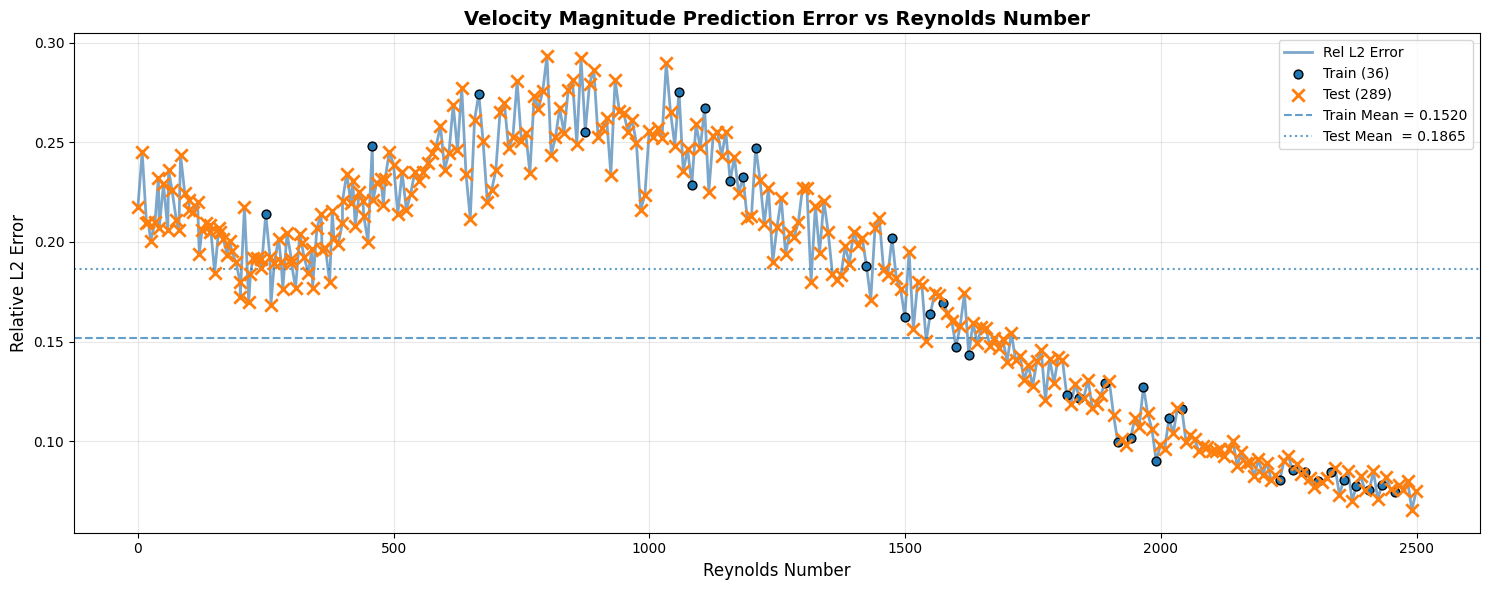

In [ ]:
df = pd.DataFrame(errors).T.reset_index()
df = df.rename(columns={"index": "Re"})
df["Re"]      = df["Re"].astype(float)
df["l2"]      = df["l2"].astype(float)
df["l2_rel"]  = df["l2_rel"].astype(float)
df["u_error"] = df["u_error"].astype(float)
df["v_error"] = df["v_error"].astype(float)
df["isTrain"] = df["isTrain"].astype(bool)
df = df.sort_values("Re")

train_df = df[df["isTrain"]]
test_df  = df[~df["isTrain"]]  # ~ instead of == False

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df["Re"], df["l2_rel"], lw=2, alpha=0.7, label="Rel L2 Error", color="steelblue")

ax.scatter(
    train_df["Re"], train_df["l2_rel"],
    s=40, marker="o", edgecolors="black",
    label=f"Train ({len(train_df)})", zorder=3
)

ax.scatter(
    test_df["Re"], test_df["l2_rel"],
    s=80, marker="x", linewidths=2,
    label=f"Test ({len(test_df)})", zorder=4
)

train_mean = train_df["l2_rel"].mean()
test_mean  = test_df["l2_rel"].mean()

ax.axhline(train_mean, linestyle="--", alpha=0.7, label=f"Train Mean = {train_mean:.4f}")
ax.axhline(test_mean,  linestyle=":",  alpha=0.7, label=f"Test Mean  = {test_mean:.4f}")

ax.set_xlabel("Reynolds Number", fontsize=12)
ax.set_ylabel("Relative L2 Error", fontsize=12)
ax.set_title("Velocity Magnitude Prediction Error vs Reynolds Number", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()  # <-- was missing ()

(array([120., 100., 101.]),
 array([1.0000e-01, 8.3310e+02, 1.6661e+03, 2.4991e+03]),
 <BarContainer object of 3 artists>)

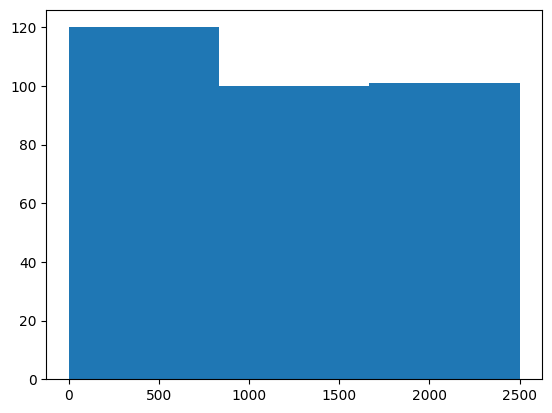

In [ ]:
start = 0.1
end = 2499.1
skip = 8.33

all = []

while start < end:
    all.append(round(start,2))
    start += skip


start = 20
end = 500
skip = 25


while start < end:
    ele = round(start,2)
    if ele not in all: all.append(ele)
    start += skip

all = sorted(all)

plt.hist(all,  bins = 3)

In [ ]:
for i in all:
    print(i, end = " ")

0.1 8.43 16.76 20 25.09 33.42 41.75 45 50.08 58.41 66.74 70 75.07 83.4 91.73 95 100.06 108.39 116.72 120 125.05 133.38 141.71 145 150.04 158.37 166.7 170 175.03 183.36 191.69 195 200.02 208.35 216.68 220 225.01 233.34 241.67 245 250.0 258.33 266.66 270 274.99 283.32 291.65 295 299.98 308.31 316.64 320 324.97 333.3 341.63 345 349.96 358.29 366.62 370 374.95 383.28 391.61 395 399.94 408.27 416.6 420 424.93 433.26 441.59 445 449.92 458.25 466.58 470 474.91 483.24 491.57 495 499.9 508.23 516.56 524.89 533.22 541.55 549.88 558.21 566.54 574.87 583.2 591.53 599.86 608.19 616.52 624.85 633.18 641.51 649.84 658.17 666.5 674.83 683.16 691.49 699.82 708.15 716.48 724.81 733.14 741.47 749.8 758.13 766.46 774.79 783.12 791.45 799.78 808.11 816.44 824.77 833.1 841.43 849.76 858.09 866.42 874.75 883.08 891.41 899.74 908.07 916.4 924.73 933.06 941.39 949.72 958.05 966.38 974.71 983.04 991.37 999.7 1008.03 1016.36 1024.69 1033.02 1041.35 1049.68 1058.01 1066.34 1074.67 1083.0 1091.33 1099.66 1107.99 1